In [ ]:
import numpy as np
import joblib
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

PROCESSED = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iiot-deeplearning\data\processed"
RESULTS   = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iiot-deeplearning\results"
MODELS    = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iiot-deeplearning\models"

X_train = np.load(os.path.join(PROCESSED, "X_train.npy"))
X_val   = np.load(os.path.join(PROCESSED, "X_val.npy"))
X_test  = np.load(os.path.join(PROCESSED, "X_test.npy"))
y_train = np.load(os.path.join(PROCESSED, "y_train.npy"))
y_val   = np.load(os.path.join(PROCESSED, "y_val.npy"))
y_test  = np.load(os.path.join(PROCESSED, "y_test.npy"))
class_weights_arr = np.load(os.path.join(PROCESSED, "class_weights.npy"), allow_pickle=True)
class_weights = {0: float(class_weights_arr[0]), 1: float(class_weights_arr[1])}

# Reshape for CNN
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_cnn   = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_cnn  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"CNN input shape: {X_train_cnn.shape}")
print(f"TensorFlow: {tf.__version__}")

# ── Build 1D-CNN ──────────────────────────────────────────────────────────
tf.random.set_seed(42)

model = keras.Sequential([
    keras.layers.Input(shape=(50, 1)),
    keras.layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    keras.layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    keras.layers.GlobalMaxPooling1D(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=100, batch_size=1024,
    class_weight=class_weights,
    callbacks=[early_stop], verbose=1)

print(f"\nStopped at epoch: {early_stop.stopped_epoch if early_stop.stopped_epoch > 0 else 100}")

# ── Evaluate ──────────────────────────────────────────────────────────────
def evaluate_dl(model, X, y, name):
    y_prob = model.predict(X, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    print(f"\n{name}:")
    print(f"  F1:        {f1_score(y, y_pred):.4f}")
    print(f"  AUC-ROC:   {roc_auc_score(y, y_prob):.4f}")
    print(f"  Precision: {precision_score(y, y_pred):.4f}")
    print(f"  Recall:    {recall_score(y, y_pred):.4f}")
    print(f"  Accuracy:  {accuracy_score(y, y_pred):.4f}")
    return y_pred, y_prob

y_pred_val, _ = evaluate_dl(model, X_val_cnn, y_val, "Validation")
y_pred_test, _ = evaluate_dl(model, X_test_cnn, y_test, "Test")

# ── Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Benign','Attack'], yticklabels=['Benign','Attack'])
plt.title('1D-CNN — DataSense IIoT 2025')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "cm_1d-cnn.png"), dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTN: {tn}  FP: {fp}  FN: {fn}  TP: {tp}")

# ── Training Curves ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('black')
for ax in [ax1, ax2]:
    ax.set_facecolor('black')

ax1.plot(history.history['loss'], color='#00cc88', label='Train Loss')
ax1.plot(history.history['val_loss'], color='#7030A0', label='Val Loss')
ax1.set_title('1D-CNN — Loss Curves', color='white')
ax1.set_xlabel('Epoch', color='white'); ax1.set_ylabel('Loss', color='white')
ax1.tick_params(colors='white'); ax1.legend(facecolor='black', labelcolor='white')
ax1.grid(color='#333333')

ax2.plot(history.history['accuracy'], color='#00cc88', label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], color='#7030A0', label='Val Accuracy')
ax2.set_title('1D-CNN — Accuracy Curves', color='white')
ax2.set_xlabel('Epoch', color='white'); ax2.set_ylabel('Accuracy', color='white')
ax2.tick_params(colors='white'); ax2.legend(facecolor='black', labelcolor='white')
ax2.grid(color='#333333')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "cnn_training_curves.png"), dpi=150, facecolor='black')
plt.show()

model.save(os.path.join(MODELS, "cnn.keras"))
print("Model saved.")

CNN input shape: (31538, 50, 1)
TensorFlow: 2.21.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 50, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,281 (130.00 KB)

 Trainable params: 33,281 (130.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.7220 - loss: 0.5698 - val_accuracy: 0.8161 - val_loss: 0.4749
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.8362 - loss: 0.4337 - val_accuracy: 0.8867 - val_loss: 0.3495
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.8888 - loss: 0.3360 - val_accuracy: 0.9034 - val_loss: 0.2720
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9039 - loss: 0.2854 - val_accuracy: 0.9148 - val_loss: 0.2442
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.9106 - loss: 0.2679 - val_accuracy: 0.9165 - val_loss: 0.2326
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.9132 - loss: 0.2576 - val_accuracy: 0.9216 - val_loss: 0.2247
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9161 - loss: 0.2482 - val_accuracy: 0.9244 - val_loss: 0.2190
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9197 - loss: 0.2428 - val_accuracy: 0.

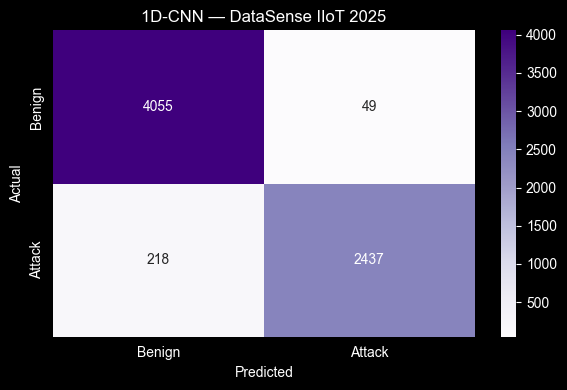


TN: 4055  FP: 49  FN: 218  TP: 2437


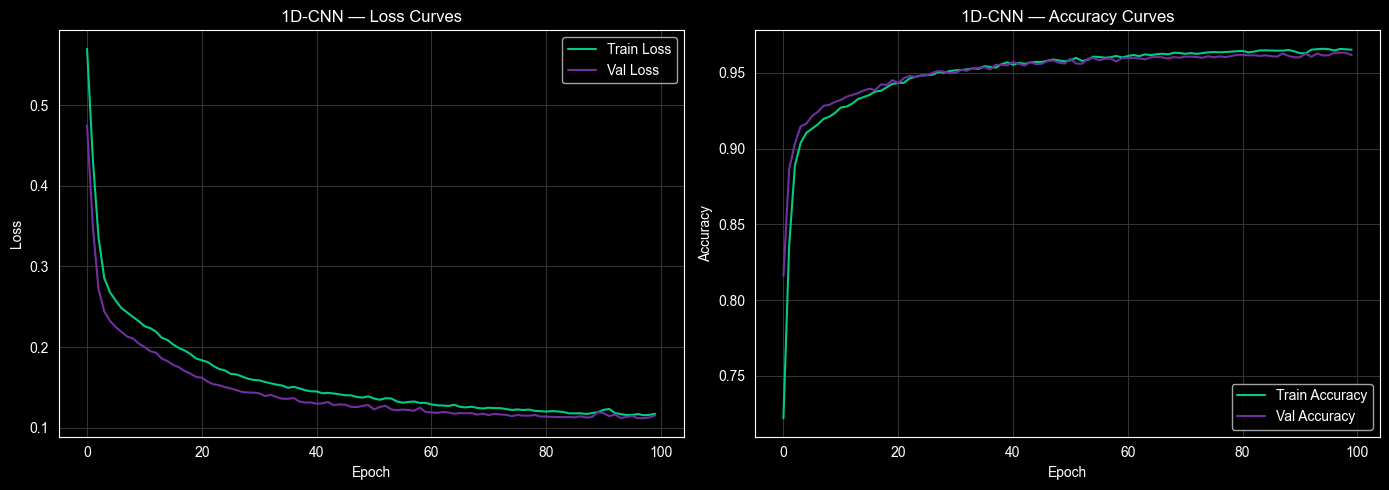

Model saved.


In [1]:
# ══════════════════════════════════════════════════════════════════════════
# DAY 6 SUMMARY — 1D-CNN on DataSense CIC IIoT 2025
# ══════════════════════════════════════════════════════════════════════════
#
# MODEL: 1D Convolutional Neural Network
# Config: 2x Conv1D (64/128 filters, kernel=3), GlobalMaxPool, Dense 64
# Converged at: epoch 100 (ran full — no early stopping)
#
# RESULTS:
#   F1:        0.9481
#   AUC-ROC:   0.9861
#   Precision: 0.9803
#   Recall:    0.9179
#   Accuracy:  0.9605
#
# KEY OBSERVATION:
#   CNN slightly below MLP on F1 (0.9481 vs 0.9537). Both ran full 100
#   epochs suggesting neither fully converged — may benefit from more
#   epochs. Classical ML still leads significantly. CNN local pattern
#   detection gains no advantage over MLP on this tabular dataset.
#
# LEADERBOARD:
#   1. XGBoost            F1=0.9678  AUC=0.9917
#   2. Random Forest      F1=0.9643  AUC=0.9916
#   3. MLP                F1=0.9537  AUC=0.9861
#   4. 1D-CNN             F1=0.9481  AUC=0.9861
#   5. Logistic Regression F1=0.8933  AUC=0.9505
# ══════════════════════════════════════════════════════════════════════════